## 2. Image display

This notebook introduces a few simple ways to display Rubin/LSST-style coadd images on UK RSP.

We will:

- connect to the `lsst-ir-fusion` Butler repo,
- discover the current VISTA collections from the registry,
- find available tract/patch deepCoadd datasets
- load one example `deepCoadd_calexp`,
- display it with `afwDisplay`,
- show the same image in sky coordinates with `astropy.wcs`,
- inspect the mask planes,
- build a quick RGB image from three bands.

### 2.1 Imports

We start with a small set of packages for plotting, WCS handling, and Butler data access.

In [1]:
import gc
from itertools import islice

import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.visualization import make_lupton_rgb

import lsst.afw.display as afwDisplay
from lsst.daf.butler import Butler

### 2.2 Plotting setup and a small cleanup helper

Image plotting can keep large arrays in memory.  
The helper below makes it easier to explicitly close figures after display.

In [2]:
afwDisplay.setDefaultBackend("matplotlib")
plt.style.use("tableau-colorblind10")

params = {
    "axes.labelsize": 15,
    "font.size": 14,
    "legend.fontsize": 13,
    "xtick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "xtick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.major.width": 1.5,
    "ytick.minor.width": 1.0,
    "ytick.major.size": 7,
    "ytick.minor.size": 4,
    "figure.figsize": (8, 6),
}
plt.rcParams.update(params)

def remove_figure(fig):
    """Close a matplotlib figure and free memory."""
    plt.close(fig)
    gc.collect()

### 2.3 Connect to the Butler repo

We use the `lsst-ir-fusion` Butler on UK RSP.

In [3]:
butler = Butler("lsst-ir-fusion")
registry = butler.registry

print("Connected to Butler repo: lsst-ir-fusion")

Connected to Butler repo: lsst-ir-fusion


### 2.4 Find the main collections

In [4]:
# Print available collections and choose the main science collections

all_collections = sorted(registry.queryCollections())

print(f"Number of collections found: {len(all_collections)}")
print("\nAvailable collections:")
for c in all_collections:
    print(" ", c)

coadd_collection = next(c for c in all_collections if "videoCoaddDetect" in c)
multivisit_collection = next(c for c in all_collections if "videoMultiVisit" in c)

print("\nSelected collections:")
print("coadd_collection      =", coadd_collection)
print("multivisit_collection =", multivisit_collection)

Number of collections found: 3

Available collections:
  skymaps
  u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z
  u/dc-park2/DRP/videoMultiVisit/20260212T193420Z

Selected collections:
coadd_collection      = u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z
multivisit_collection = u/dc-park2/DRP/videoMultiVisit/20260212T193420Z


### 2.5 Open a Butler view for image access

We create a Butler that searches the selected coadd collection by default.

In [5]:
coadd_butler = Butler("lsst-ir-fusion", collections=coadd_collection)

### 2.6 Find available tract/patch `deepCoadd_calexp` datasets


In [6]:
# Find available tract/patch combinations in the coadd collection
from collections import defaultdict

# Group patches by tract
patches_by_tract = defaultdict(set)

for ref in registry.queryDatasets("deepCoadd_calexp", collections=coadd_collection):
    d = dict(ref.dataId.mapping)
    patches_by_tract[d["tract"]].add(d["patch"])

# Print one line per tract
for tract in sorted(patches_by_tract):
    patch_list = sorted(patches_by_tract[tract])
    patch_text = ", ".join(str(p) for p in patch_list)
    print(f"tract {tract}: {patch_text}")

tract 8523: 18, 19, 20, 21, 22, 23, 24, 27, 28, 29, 30, 31, 32, 33, 36, 37, 38, 39, 40, 41, 42, 45, 46, 47, 48, 49, 50, 51, 54, 55, 56, 57, 58, 59, 60, 63, 64, 65, 66, 67, 68, 69, 72, 73, 74, 75, 76, 77, 78
tract 8524: 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80
tract 8525: 31, 32, 33, 34, 35, 40, 41, 42, 43, 44, 49, 50, 51, 52, 53, 58, 59, 60, 61, 62, 67, 68, 69, 70, 71, 76, 77, 78, 79, 80
tract 8765: 0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23, 24
tract 8766: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29
tract 8767: 4, 5, 6, 7, 8, 13, 14, 15, 16, 17, 22, 23, 24, 25, 26, 31, 32, 33, 34, 35


#### 2.6.1 Select one tract and patch from list to display it.

In [7]:
skymap_name = "hscPdr2"
my_tract = 8524
my_patch = 30
my_band = "K"

sample_data_id = {
    "skymap": skymap_name,
    "tract": my_tract,
    "patch": my_patch,
    "band": my_band,
}

print("Selected data ID:")
print(sample_data_id)

Selected data ID:
{'skymap': 'hscPdr2', 'tract': 8524, 'patch': 30, 'band': 'K'}


### 2.7 Load one coadd image

We now retrieve the selected `deepCoadd_calexp`.

In [8]:
my_deepCoadd = coadd_butler.get("deepCoadd_calexp", **sample_data_id)

print("Loaded deepCoadd_calexp")
print("BBox width  :", my_deepCoadd.getBBox().getWidth())
print("BBox height :", my_deepCoadd.getBBox().getHeight())

Loaded deepCoadd_calexp
BBox width  : 4200
BBox height : 4200


### 2.8 Display the image with `afwDisplay`

This is the quickest Rubin-style way to inspect an image.

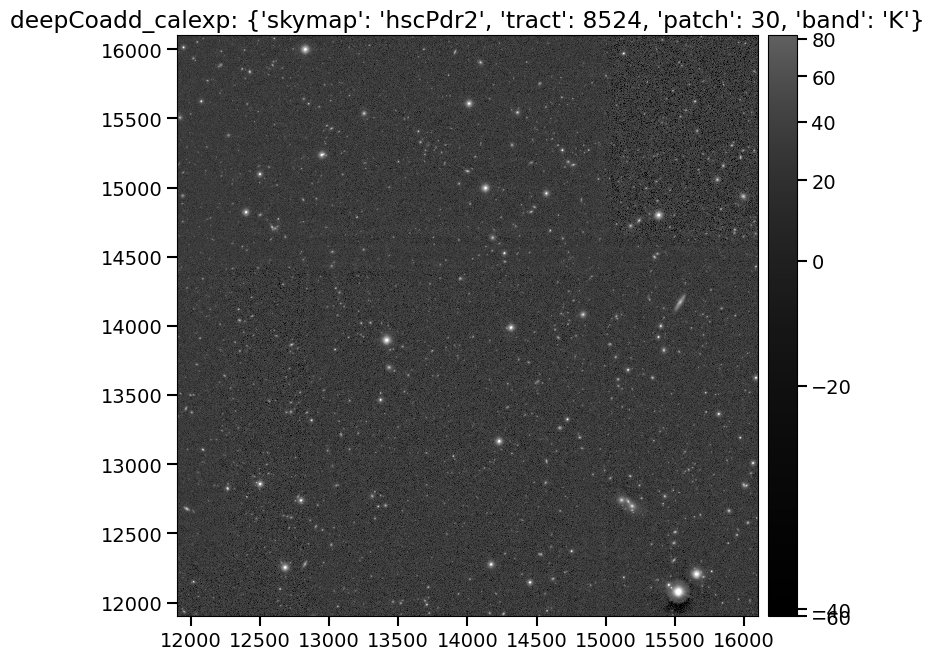

In [9]:
fig = plt.figure(figsize=(8, 8))
display = afwDisplay.Display(frame=fig)
display.scale("asinh", "zscale")
display.mtv(my_deepCoadd.image)
plt.title(f"deepCoadd_calexp: {sample_data_id}")
plt.show()
remove_figure(fig)

### 2.9 Display the image in sky coordinates

For many checks it is helpful to show the image in RA/Dec instead of pixel coordinates.

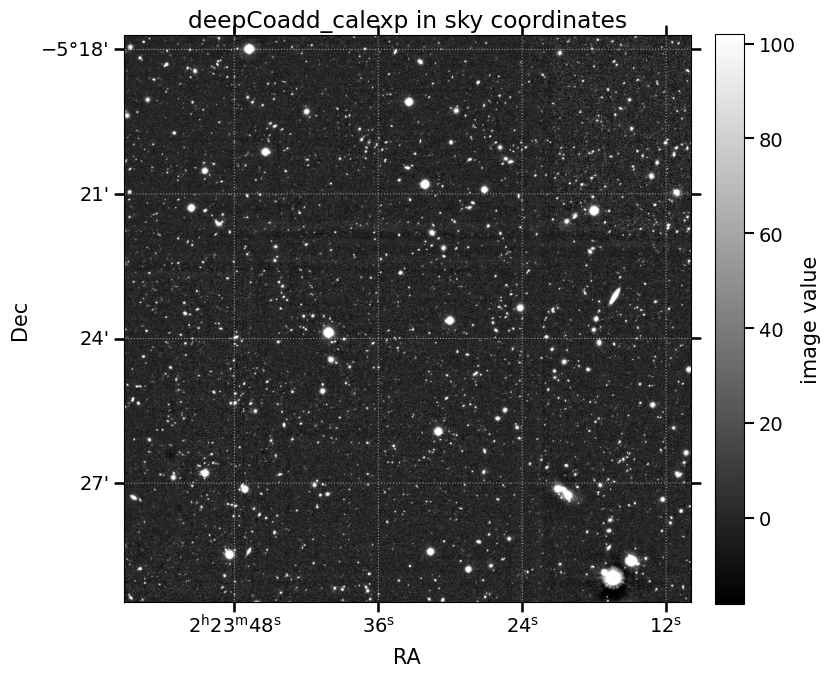

In [10]:
bbox = my_deepCoadd.getBBox()
extent = (bbox.beginX, bbox.endX, bbox.beginY, bbox.endY)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=WCS(my_deepCoadd.getWcs().getFitsMetadata()))

vmin, vmax = np.nanpercentile(my_deepCoadd.image.array, [5, 99])

im = ax.imshow(
    my_deepCoadd.image.array,
    cmap="gray",
    origin="lower",
    extent=extent,
    vmin=vmin,
    vmax=vmax,
)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="white", ls=":", alpha=0.5)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="image value")
plt.title("deepCoadd_calexp in sky coordinates")
plt.show()
remove_figure(fig)

### 2.10 Inspect the mask planes

Mask planes tell us which pixels are flagged for different reasons such as detection, interpolation, saturation, and so on.

In [11]:
mask_plane_dict = my_deepCoadd.mask.getMaskPlaneDict()

print("Mask planes in this image:\n")
for name, bit in sorted(mask_plane_dict.items(), key=lambda x: x[1]):
    print(f"{bit:2d}  {name}")

Mask planes in this image:

 0  BAD
 1  SAT
 2  INTRP
 3  CR
 4  EDGE
 5  DETECTED
 6  DETECTED_NEGATIVE
 7  SUSPECT
 8  NO_DATA
 9  VIGNETTED
10  STREAK
11  CLIPPED
12  INEXACT_PSF
13  NOT_DEBLENDED
14  REJECTED
15  SENSOR_EDGE
16  UNMASKEDNAN


### 2.11 Show the image and mask overlay

Here we overplot the mask on top of the image and make the overlay partly transparent.

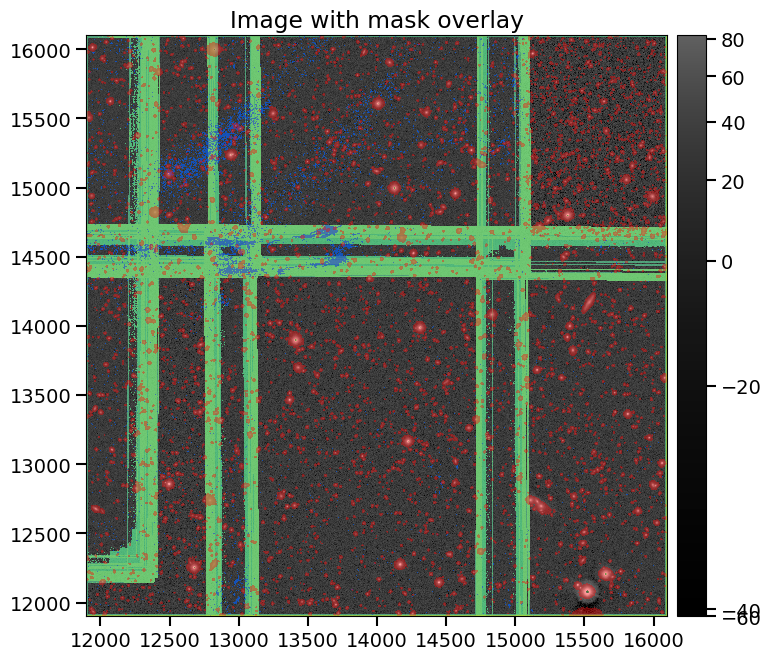

In [12]:
fig = plt.figure(figsize=(8, 8))
display = afwDisplay.Display(frame=fig)
display.scale("asinh", "zscale")
display.setMaskTransparency(60)

if "DETECTED" in mask_plane_dict:
    display.setMaskPlaneColor("DETECTED", "red")
if "BAD" in mask_plane_dict:
    display.setMaskPlaneColor("BAD", "cyan")

display.mtv(my_deepCoadd)
plt.title("Image with mask overlay")
plt.show()
remove_figure(fig)

### 2.12 Build a simple RGB image

If three suitable bands exist for the same tract and patch, we can make a quick colour composite.

For VISTA data, a natural simple choice is:

- red = `K`
- green = `J`
- blue = `Y`

This is only for visualisation, not for quantitative analysis.

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/astropy/visualization/lupton_rgb.py:645: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


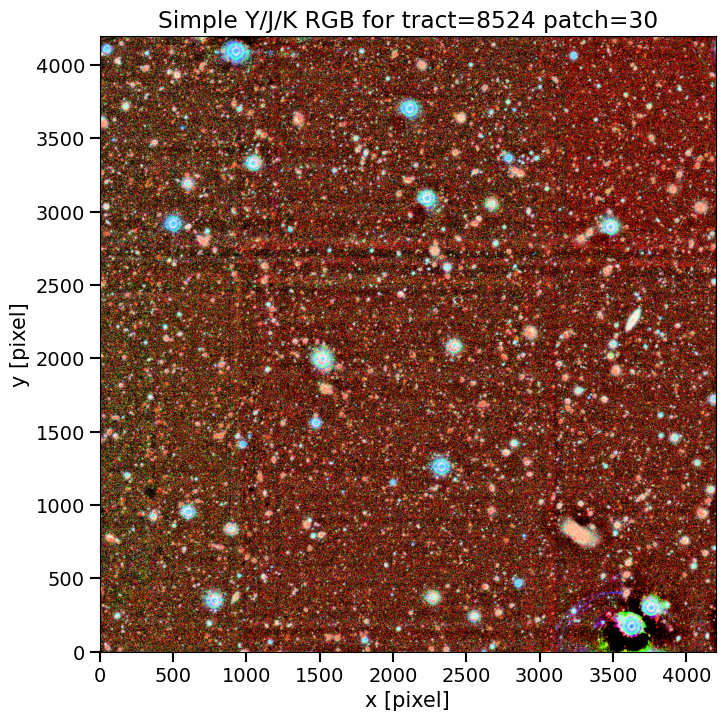

In [13]:
base_data_id = sample_data_id.copy()
rgb_bands = {"red": "K", "green": "J", "blue": "Y"}

rgb_arrays = {}
missing_bands = []

for color, band in rgb_bands.items():
    data_id = base_data_id.copy()
    data_id["band"] = band
    try:
        exp = coadd_butler.get("deepCoadd_calexp", **data_id)
        rgb_arrays[color] = exp.image.array
    except Exception:
        missing_bands.append(band)

if missing_bands:
    print("RGB example skipped because these bands were not available for the same tract/patch:")
    print(missing_bands)
else:
    rgb = make_lupton_rgb(
        rgb_arrays["red"],
        rgb_arrays["green"],
        rgb_arrays["blue"],
        stretch=0.5,
        Q=8,
    )

    fig = plt.figure(figsize=(8, 8))
    plt.imshow(rgb, origin="lower")
    plt.title(f"Simple Y/J/K RGB for tract={base_data_id.get('tract')} patch={base_data_id.get('patch')}")
    plt.xlabel("x [pixel]")
    plt.ylabel("y [pixel]")
    plt.show()
    remove_figure(fig)